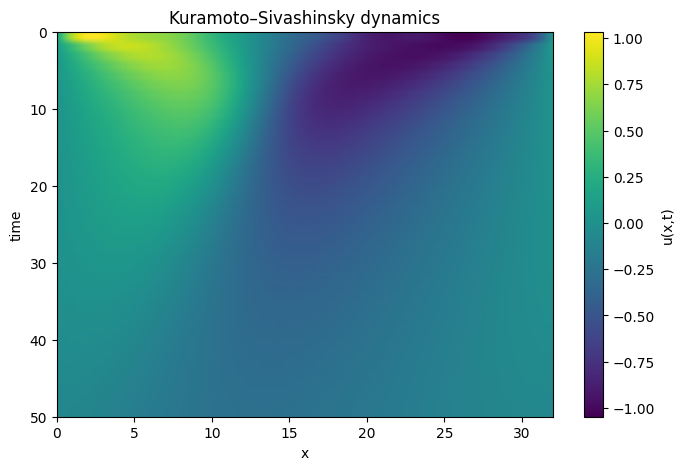

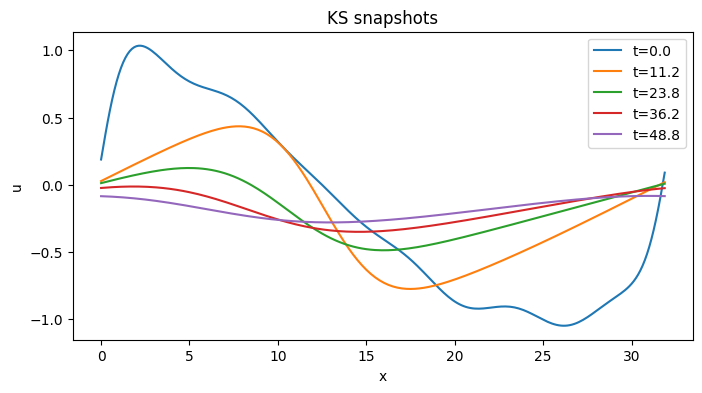

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parameters
# ============================================================
L  = 32.0
nx = 256
dx = L / nx

T  = 50.0
dt = 0.25   # MUCH larger allowed now

nu = 1.0
mu = 1.0

nt = int(T / dt)

x = np.linspace(0, L, nx, endpoint=False)

# ============================================================
# Initial condition (small perturbation)
# ============================================================
u = np.cos(x / 8.0) * (1 + 0.1*np.sin(x))

# ============================================================
# Fourier setup
# ============================================================
k = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
k2 = k**2
k4 = k**4

# linear operator (stiff part)
L_hat = -nu * k2 - mu * k4

# ============================================================
# Storage
# ============================================================
history = []

# ============================================================
# Time stepping (semi-implicit)
# ============================================================
for n in range(nt):

    u_hat = np.fft.fft(u)

    # nonlinear term: u*u_x
    ux = np.fft.ifft(1j * k * u_hat).real
    nonlinear = -u * ux

    nonlinear_hat = np.fft.fft(nonlinear)

    # semi-implicit update
    u_hat = (u_hat + dt * nonlinear_hat) / (1 - dt * L_hat)

    u = np.fft.ifft(u_hat).real

    if n % 5 == 0:
        history.append(u.copy())

history = np.array(history)

# ============================================================
# Plot: space-time chaos
# ============================================================
plt.figure(figsize=(8, 5))
plt.imshow(history, extent=[0, L, T, 0], aspect='auto')
plt.colorbar(label='u(x,t)')
plt.xlabel('x')
plt.ylabel('time')
plt.title('Kuramoto–Sivashinsky dynamics')
plt.show()

# ============================================================
# Snapshots
# ============================================================
plt.figure(figsize=(8, 4))
for i, idx in enumerate(np.linspace(0, len(history)-1, 5, dtype=int)):
    plt.plot(x, history[idx], label=f't={idx*5*dt:.1f}')
plt.legend()
plt.xlabel('x')
plt.ylabel('u')
plt.title('KS snapshots')
plt.show()